<h1 align="center" id="top"><u>RL project</u></h1>
<h3 align="center"><u>Clément MOLLY-MITTON | Diane VERBECQ | Fanny BADOULES | Ghiles KEMICHE</u></h3>

# Table of Contents
***
1. [Import](#import)
2. [Testing](#testing)

## Import
***

In [1]:
from pathlib import Path

from rl_project.benchmark.benchmark import HighwayBenchmark
from rl_project.benchmark.typing import BenchmarkConfig
from rl_project.models.core.typing import ModelType
from rl_project.models.factory import load_model
from scripts.envs.factory import get_env_config
from scripts.envs.typing import EnvType
from scripts.utils.display import display_episode

## Testing
***

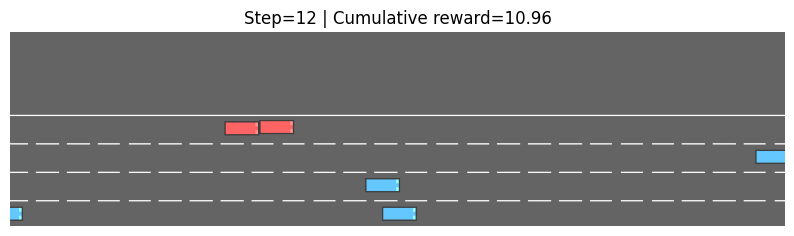

{'episode_reward': 10.959012213979552,
 'episode_length': 12,
 'crashed': True,
 'offroad': False,
 'mean_speed': 28.956522350646114}

In [2]:
env_type = EnvType.BASELINE
env_id, env_config = get_env_config(env_type)
env_config["offscreen_rendering"] = True

benchmark = HighwayBenchmark(
    config=BenchmarkConfig(
        env_id=env_id,
        env_config=env_config,
    ),
    render_mode="rgb_array",
)
seed = 1
env = benchmark.make_env(seed=seed)

model_type = ModelType.DQN
model_path = (
    Path.cwd().parents[2]
    / "data"
    / "training"
    / model_type.value
    / env_type.value
    / f"seed_{seed}"
    / f"model_{model_type.value}_{env_type.value}_seed_{seed}_final.pt"
)
model = load_model(model_type, model_path)

stats = display_episode(
    env=env,
    model=model,
    greedy=True,
    sleep_time=0.03,
)
stats